# Sparse-FCL: Federated Continual Learning on CIFAR-10
**Architecture**: 6-layer CNN | **Sparsity**: 90% | **Clients**: 10 | **Non-IID**: Dirichlet(α=10)

CIFAR-10 is split into two tasks:
- **Task 1**: airplane, automobile, bird, cat, deer (classes 0–4)
- **Task 2**: dog, frog, horse, ship, truck (classes 5–9)

In [7]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install torchvision onnx onnxruntime --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy
import os
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 38.5 MB/s eta 0:00:00
Using device: cuda


## 1. Hyperparameters

In [8]:
# ── Global hyperparameters ────────────────────────────────────────────────────
NUM_CLIENTS      = 10       # Number of federated clients
FL_ROUNDS        = 10       # Communication rounds per task
LOCAL_EPOCHS     = 5        # Local epochs per round (paper spec)
BATCH_SIZE       = 128      # Batch size (paper spec)
SPARSITY         = 0.9      # 90% weights zeroed (paper spec)
DIRICHLET_ALPHA  = 10.0     # Non-IID heterogeneity (paper spec)
EWC_LAMBDA       = 5000     # EWC penalty strength
LR               = 1e-3     # Adam learning rate
NUM_CLASSES      = 10       # CIFAR-10
TASK1_CLASSES    = list(range(0, 5))   # airplane, automobile, bird, cat, deer
TASK2_CLASSES    = list(range(5, 10))  # dog, frog, horse, ship, truck

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print('Hyperparameters set.')
print(f'  Task 1 classes: {[CLASSES[c] for c in TASK1_CLASSES]}')
print(f'  Task 2 classes: {[CLASSES[c] for c in TASK2_CLASSES]}')

Hyperparameters set.
  Task 1 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer']
  Task 2 classes: ['dog', 'frog', 'horse', 'ship', 'truck']


## 2. Dataset + Non-IID Dirichlet Split

In [9]:
# ── Data transforms ───────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=train_transform)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=test_transform)

print(f'Train: {len(full_train)} | Test: {len(full_test)}')

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Train: 50000 | Test: 10000


In [10]:
# ── Task subset helper ────────────────────────────────────────────────────────
def get_task_subset(dataset, class_ids):
    """Return subset containing only the given class IDs."""
    indices = [i for i, lbl in enumerate(dataset.targets) if lbl in class_ids]
    return Subset(dataset, indices)

task1_train = get_task_subset(full_train, TASK1_CLASSES)
task1_test  = get_task_subset(full_test,  TASK1_CLASSES)
task2_train = get_task_subset(full_train, TASK2_CLASSES)
task2_test  = get_task_subset(full_test,  TASK2_CLASSES)

print(f'Task 1 — train: {len(task1_train)}, test: {len(task1_test)}')
print(f'Task 2 — train: {len(task2_train)}, test: {len(task2_test)}')

Task 1 — train: 25000, test: 5000
Task 2 — train: 25000, test: 5000


In [11]:
# ── Dirichlet Non-IID split across clients ────────────────────────────────────
# Simulates real IoT/edge scenarios where devices see heterogeneous data.
# alpha=10 produces moderately heterogeneous distributions (paper spec).

def dirichlet_split(dataset, num_clients, alpha=DIRICHLET_ALPHA):
    """
    Split dataset into num_clients shards using Dirichlet(alpha).
    Lower alpha -> more heterogeneous (each client gets fewer classes).
    Higher alpha -> more uniform (each client gets balanced classes).
    alpha=10 gives mild heterogeneity as specified in the paper.
    """
    # Extract labels from the dataset
    if hasattr(dataset, 'targets'):
        all_labels = np.array(dataset.targets)
        all_indices = np.arange(len(dataset))
    else:
        # Subset: retrieve labels via .dataset.targets and .indices
        all_indices = np.array(dataset.indices)
        all_labels  = np.array(dataset.dataset.targets)[all_indices]

    unique_classes = np.unique(all_labels)
    client_indices = [[] for _ in range(num_clients)]

    for cls in unique_classes:
        cls_mask    = all_labels == cls
        cls_idx     = all_indices[cls_mask]
        np.random.shuffle(cls_idx)

        # Sample proportions from Dirichlet
        proportions = np.random.dirichlet(np.ones(num_clients) * alpha)
        # Convert to integer split points
        split_sizes = (proportions * len(cls_idx)).astype(int)
        # Fix rounding: make sure sizes sum to len(cls_idx)
        split_sizes[-1] = len(cls_idx) - split_sizes[:-1].sum()
        split_sizes = np.maximum(split_sizes, 0)

        splits = np.split(cls_idx, np.cumsum(split_sizes)[:-1])
        for i, split in enumerate(splits):
            client_indices[i].extend(split.tolist())

    # Build DataLoaders for each client
    loaders = []
    for idx_list in client_indices:
        if len(idx_list) == 0:
            continue  # skip empty clients (rare at alpha=10)
        # Map back to the original dataset (for Subsets, indices are already global)
        if hasattr(dataset, 'targets'):
            subset = Subset(dataset, idx_list)
        else:
            subset = Subset(dataset.dataset, idx_list)
        loaders.append(DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, pin_memory=True))
    return loaders

# Pre-build loaders so they can be reused
client_loaders_t1 = dirichlet_split(task1_train, NUM_CLIENTS)
client_loaders_t2 = dirichlet_split(task2_train, NUM_CLIENTS)

print(f'Task 1: {len(client_loaders_t1)} client loaders')
print(f'Task 2: {len(client_loaders_t2)} client loaders')
sizes_t1 = [len(l.dataset) for l in client_loaders_t1]
print(f'  Samples per client (T1): min={min(sizes_t1)}, max={max(sizes_t1)}, '
      f'mean={np.mean(sizes_t1):.0f}')

Task 1: 10 client loaders
Task 2: 10 client loaders
  Samples per client (T1): min=1980, max=3246, mean=2500


## 3. Model Architecture
6-layer CNN (paper spec): Conv64 → Conv64+Pool → Conv128 → Conv128+Pool → FC1024 → Out10  
Task masking at the output layer blocks irrelevant class neurons.

In [12]:
# ── Task mask helper ──────────────────────────────────────────────────────────
def get_task_mask(task_id, num_classes=NUM_CLASSES):
    """
    Returns a 1D tensor of shape (num_classes,) where:
      task_id=1  ->  classes 0-4  are 1, rest 0
      task_id=2  ->  classes 5-9  are 1, rest 0
    This physically blocks output neurons belonging to other tasks.
    """
    mask = torch.zeros(num_classes)
    if task_id == 1:
        mask[:5] = 1.0
    elif task_id == 2:
        mask[5:] = 1.0
    return mask.to(device)


# ── 6-layer CNN (Sparse-FCL architecture) ────────────────────────────────────
class SparseFCL_CNN(nn.Module):
    """
    6-layer CNN as specified in the paper:
      Block 1: Conv(64,3x3) -> BN -> ReLU -> Conv(64,3x3) -> BN -> ReLU -> MaxPool
      Block 2: Conv(128,3x3) -> BN -> ReLU -> Conv(128,3x3) -> BN -> ReLU -> MaxPool
      FC1:  8192 -> 1024  (8*8*128 = 8192 for CIFAR-32x32)
      FC2:  1024 -> 10
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super(SparseFCL_CNN, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(3,  64, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)   # 32x32 -> 16x16

        # --- Block 2 ---
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn4   = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)   # 16x16 -> 8x8

        # --- FC layers ---
        # 8 * 8 * 128 = 8192  (paper spec for CIFAR)
        self.fc1     = nn.Linear(8192, 1024)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(1024, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, task_mask=None):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)                      # -> (B, 64, 16, 16)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)                      # -> (B, 128, 8, 8)

        # Flatten: 128 * 8 * 8 = 8192
        x = x.view(x.size(0), -1)

        # FC layers
        x = self.dropout(F.relu(self.fc1(x)))  # -> (B, 1024)
        x = self.fc2(x)                         # -> (B, 10)

        # Task masking: zero-out neurons belonging to other tasks
        if task_mask is not None:
            x = x * task_mask.unsqueeze(0)      # broadcast over batch

        return x


# ── Sanity check ──────────────────────────────────────────────────────────────
model_test = SparseFCL_CNN().to(device)
dummy      = torch.randn(4, 3, 32, 32).to(device)
mask_t1    = get_task_mask(1)
out        = model_test(dummy, mask_t1)

print(f'Input shape  : {dummy.shape}')
print(f'Output shape : {out.shape}')
print(f'Task 1 mask  : {mask_t1.cpu().tolist()}')
print(f'Total params : {sum(p.numel() for p in model_test.parameters()):,}')
print(f'FC1 input dim: 8192  (= 8x8x128, CIFAR-32x32 spec)')

Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 10])
Task 1 mask  : [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Total params : 8,660,810
FC1 input dim: 8192  (= 8x8x128, CIFAR-32x32 spec)


## 4. Sparsity Engine (DST — Dynamic Sparse Training)
90% of weights are always zeroed. Regrow 10% of dead weights after each round.

In [13]:
# ── Apply sparsity mask ───────────────────────────────────────────────────────
def apply_sparsity_mask(model, sparsity=SPARSITY):
    """
    Zero out the bottom `sparsity` fraction of weights by magnitude.
    Returns dict of binary masks {param_name: mask_tensor}.
    At sparsity=0.9, only the top 10% of weights (by absolute value) survive.
    """
    masks = {}
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() > 1:  # skip biases/BN
                flat      = param.data.abs().view(-1).float()
                threshold = torch.quantile(flat, sparsity)
                mask      = (param.data.abs() >= threshold).float()
                param.data.mul_(mask)
                masks[name] = mask
    return masks


# ── Regrow dead weights ───────────────────────────────────────────────────────
def regrow_weights(model, masks, regrow_fraction=0.1):
    """
    Randomly reactivate `regrow_fraction` of currently-dead weights with
    small random values, enabling the network to explore new sparse topologies.
    """
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in masks:
                continue
            dead_mask = (masks[name] == 0).view(-1)
            num_dead  = dead_mask.sum().item()
            if num_dead == 0:
                continue
            num_regrow   = max(1, int(num_dead * regrow_fraction))
            dead_indices = dead_mask.nonzero(as_tuple=False).squeeze(1)
            perm         = torch.randperm(len(dead_indices), device=param.device)
            revive       = dead_indices[perm[:num_regrow]]
            flat         = param.data.view(-1)
            flat[revive] = torch.randn(num_regrow, device=param.device) * 0.01
    return model


# ── Enforce masks during forward (re-apply after optimizer step) ──────────────
def enforce_masks(model, masks):
    """Re-zero pruned weights after an optimizer step."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in masks:
                param.data.mul_(masks[name].to(param.device))


print(f'DST configured: {SPARSITY*100:.0f}% sparsity '
      f'(top {(1-SPARSITY)*100:.0f}% weights active)')

DST configured: 90% sparsity (top 10% weights active)


## 5. EWC — Elastic Weight Consolidation
Prevents catastrophic forgetting by penalising changes to weights that were important for Task 1.

In [14]:
# ── Compute Fisher Information Matrix ─────────────────────────────────────────
def compute_fisher(model, dataloader, task_mask, num_samples=1000):
    """
    Diagonal Fisher: F_i = E[(d/d_theta_i log p(y|x))^2]
    Higher F_i => that weight was more important for this task.
    """
    model.eval()
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    count  = 0

    for images, labels in dataloader:
        if count >= num_samples:
            break
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        output = model(images, task_mask)
        loss   = F.cross_entropy(output, labels)
        loss.backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach() ** 2
        count += images.size(0)

    for n in fisher:
        fisher[n] /= max(count, 1)
    print(f'Fisher computed over {count} samples.')
    return fisher


# ── EWC penalty term ──────────────────────────────────────────────────────────
def ewc_penalty(model, fisher, theta_star, ewc_lambda=EWC_LAMBDA):
    """
    penalty = (lambda/2) * sum_i [ F_i * (theta_i - theta*_i)^2 ]
    Added to the cross-entropy loss during Task 2 training.
    This SURVIVES federated_average() because it acts at gradient computation.
    """
    pen = 0.0
    for n, p in model.named_parameters():
        if n in fisher:
            pen += (fisher[n] * (p - theta_star[n]).pow(2)).sum()
    return (ewc_lambda / 2.0) * pen


print('EWC utilities ready.')

EWC utilities ready.


## 6. Federated Aggregation
Weighted FedAvg. Clients send only sparse weights + masks (~80% communication reduction).

In [15]:
# ── Weighted FedAvg ───────────────────────────────────────────────────────────
def federated_average(global_model, client_models, client_loaders):
    """
    Aggregate client models using dataset-size-weighted averaging.
    Only the sparse (non-zero) weights are logically transmitted,
    giving ~80% communication reduction at 90% sparsity.
    """
    sizes = [len(ld.dataset) for ld in client_loaders]
    total = sum(sizes)
    g_state = global_model.state_dict()

    for key in g_state.keys():
        weighted = torch.stack([
            (sizes[i] / total) * cm.state_dict()[key].float()
            for i, cm in enumerate(client_models)
        ]).sum(dim=0)
        g_state[key] = weighted

    global_model.load_state_dict(g_state)
    return global_model


print('FedAvg aggregation ready.')

FedAvg aggregation ready.


## 7. Task-Adaptive Topology Exploration
Cosine similarity check determines whether to reuse or rewire sparse connections.

In [16]:
# ── Activation hook store ─────────────────────────────────────────────────────
_act_store = {}

def _hook_fn(name):
    def hook(module, inp, out):
        _act_store[name] = out.detach()
    return hook


def mean_fc1_activations(model, dataloader, task_mask, max_batches=20):
    """Compute mean fc1 activations on a dataloader."""
    handle = model.fc1.register_forward_hook(_hook_fn('fc1'))
    model.eval()
    acts = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(dataloader):
            if i >= max_batches:
                break
            model(imgs.to(device), task_mask)
            acts.append(F.relu(_act_store['fc1']))
    handle.remove()
    return torch.cat(acts, dim=0).mean(dim=0)   # (1024,)


def select_stable_neurons(model, dataloader, task_mask, top_fraction=0.3):
    """Return indices of the most consistently activated fc1 neurons."""
    mean_act = mean_fc1_activations(model, dataloader, task_mask)
    k        = max(1, int(top_fraction * mean_act.shape[0]))
    _, idx   = torch.topk(mean_act, k)
    print(f'Stable neurons: top {k}/{mean_act.shape[0]}')
    return idx


def topology_rewire(model, stable_neurons, masks, task_mask_t2):
    """
    If tasks are DIFFERENT:
      - Keep stable (important) neurons from Task 1.
      - Reinitialise plastic neurons to explore new sparse paths for Task 2.
    """
    with torch.no_grad():
        fc1_w         = model.fc1.weight          # (1024, 8192)
        all_neurons   = set(range(fc1_w.shape[0]))
        plastic       = list(all_neurons - set(stable_neurons.cpu().tolist()))
        fc1_w.data[plastic] = (
            torch.randn(len(plastic), fc1_w.shape[1], device=device) * 0.01
        )
    # Re-apply sparsity after reinit
    new_masks = apply_sparsity_mask(model, SPARSITY)
    print(f'Rewired {len(plastic)} plastic neurons, kept {len(stable_neurons)} stable.')
    return new_masks


print('Topology exploration utilities ready.')

Topology exploration utilities ready.


## 8. Local Training Loop

In [17]:
# ── Local client training ─────────────────────────────────────────────────────
def local_train(model, loader, task_mask, optimizer, epochs=LOCAL_EPOCHS,
                masks=None, fisher=None, theta_star=None, ewc_lam=EWC_LAMBDA):
    """
    Train `model` for `epochs` local epochs on `loader`.
    - Applies task mask at every forward pass.
    - Adds EWC penalty if fisher and theta_star are provided (Task 2 only).
    - Re-enforces sparsity mask after every optimizer step.

    FIX: masks[name].to(param.device) prevents CUDA/CPU mismatch that caused
    crashes when export cells inadvertently moved global_model to CPU.
    """
    model.train()
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches  = 0

    for _ in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs   = model(images, task_mask)
            task_loss = criterion(outputs, labels)

            # EWC penalty (only during Task 2)
            if fisher is not None and theta_star is not None:
                loss = task_loss + ewc_penalty(model, fisher, theta_star, ewc_lam)
            else:
                loss = task_loss

            loss.backward()
            optimizer.step()

            # Re-enforce sparsity: zero out pruned weights after gradient update
            if masks:
                enforce_masks(model, masks)

            total_loss += task_loss.item()
            n_batches  += 1

    avg_loss = total_loss / max(n_batches, 1)
    return model, avg_loss


print('local_train ready.')

local_train ready.


## 9. Task 1 Federated Training

In [18]:
# ── Task 1 Training ───────────────────────────────────────────────────────────
print('=' * 55)
print('TASK 1 FEDERATED TRAINING')
print('  Classes: airplane, automobile, bird, cat, deer')
print('=' * 55)

global_model    = SparseFCL_CNN(num_classes=NUM_CLASSES).to(device)
global_masks    = apply_sparsity_mask(global_model, SPARSITY)
task1_mask      = get_task_mask(1)
task1_round_losses = []

for fl_round in range(FL_ROUNDS):
    print(f'\n[Round {fl_round+1}/{FL_ROUNDS}]')
    client_models = []
    round_losses  = []

    for cid, loader in enumerate(client_loaders_t1):
        cm  = copy.deepcopy(global_model)
        opt = optim.Adam(cm.parameters(), lr=LR, weight_decay=1e-4)
        cm, loss = local_train(
            cm, loader, task1_mask, opt,
            epochs=LOCAL_EPOCHS, masks=global_masks
        )
        client_models.append(cm)
        round_losses.append(loss)
        print(f'  Client {cid+1:2d} | loss: {loss:.4f}')

    # Federated aggregation
    global_model = federated_average(global_model, client_models, client_loaders_t1)

    # DST: update masks + allow topology exploration
    global_masks = apply_sparsity_mask(global_model, SPARSITY)
    global_model = regrow_weights(global_model, global_masks)

    avg = np.mean(round_losses)
    task1_round_losses.append(avg)
    print(f'  --> Global avg loss: {avg:.4f}')

torch.save(global_model.state_dict(), 'model_task1.pth')
print('\nTask 1 model saved: model_task1.pth')

TASK 1 FEDERATED TRAINING
  Classes: airplane, automobile, bird, cat, deer

[Round 1/10]
  Client  1 | loss: 1.3177
  Client  2 | loss: 1.4427
  Client  3 | loss: 1.3458
  Client  4 | loss: 1.4170
  Client  5 | loss: 1.3538
  Client  6 | loss: 1.4080
  Client  7 | loss: 1.3640
  Client  8 | loss: 1.4101
  Client  9 | loss: 1.3173
  Client 10 | loss: 1.3562
  --> Global avg loss: 1.3733

[Round 2/10]
  Client  1 | loss: 1.1137
  Client  2 | loss: 1.1987
  Client  3 | loss: 1.1161
  Client  4 | loss: 1.1398
  Client  5 | loss: 1.1551
  Client  6 | loss: 1.1574
  Client  7 | loss: 1.0781
  Client  8 | loss: 1.1600
  Client  9 | loss: 1.0882
  Client 10 | loss: 1.1440
  --> Global avg loss: 1.1351

[Round 3/10]
  Client  1 | loss: 1.0219
  Client  2 | loss: 1.1196
  Client  3 | loss: 1.0010
  Client  4 | loss: 1.0311
  Client  5 | loss: 1.0376
  Client  6 | loss: 1.0195
  Client  7 | loss: 0.9701
  Client  8 | loss: 1.0579
  Client  9 | loss: 0.9732
  Client 10 | loss: 1.0656
  --> Global 

## 10. EWC + Topology Check (Between Tasks)

In [19]:
# ── Compute Fisher + anchor weights for EWC ───────────────────────────────────
# Must happen AFTER Task 1 training, BEFORE Task 2 training.
task1_full_loader = DataLoader(task1_train, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

print('Computing Fisher Information Matrix...')
fisher_t1     = compute_fisher(global_model, task1_full_loader, task1_mask, num_samples=2000)
theta_star_t1 = {n: p.clone().detach() for n, p in global_model.named_parameters()}
print('EWC anchor weights saved.')

# ── Select stable neurons (preserve across tasks) ─────────────────────────────
stable_neurons = select_stable_neurons(global_model, task1_full_loader, task1_mask)

# ── Task-Adaptive Topology: cosine similarity check ──────────────────────────
task2_sample_loader = DataLoader(task2_train, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=2, pin_memory=True)
task2_mask = get_task_mask(2)

acts_t1 = mean_fc1_activations(global_model, task1_full_loader, task1_mask)
acts_t2 = mean_fc1_activations(global_model, task2_sample_loader, task2_mask)
cos_sim  = F.cosine_similarity(acts_t1.unsqueeze(0), acts_t2.unsqueeze(0)).item()

SIMILARITY_THRESHOLD = 0.7
print(f'\nTask 1 vs Task 2 cosine similarity: {cos_sim:.4f}')

if cos_sim >= SIMILARITY_THRESHOLD:
    print(f'Tasks SIMILAR (>= {SIMILARITY_THRESHOLD}) -> reusing sparse topology (transfer).')
    rewired_masks = global_masks
else:
    print(f'Tasks DIFFERENT (< {SIMILARITY_THRESHOLD}) -> rewiring plastic neurons.')
    rewired_masks = topology_rewire(global_model, stable_neurons, global_masks, task2_mask)

print('Topology decision complete.')

Computing Fisher Information Matrix...
Fisher computed over 2048 samples.
EWC anchor weights saved.
Stable neurons: top 307/1024

Task 1 vs Task 2 cosine similarity: 0.9972
Tasks SIMILAR (>= 0.7) -> reusing sparse topology (transfer).
Topology decision complete.


## 11. Task 2 Federated Training (with EWC)

In [20]:
# ── Task 2 Training ───────────────────────────────────────────────────────────
print('=' * 55)
print('TASK 2 FEDERATED TRAINING (EWC active)')
print('  Classes: dog, frog, horse, ship, truck')
print(f'  EWC lambda = {EWC_LAMBDA}')
print('=' * 55)

task2_round_losses = []

for fl_round in range(FL_ROUNDS):
    print(f'\n[Round {fl_round+1}/{FL_ROUNDS}]')
    client_models = []
    round_losses  = []

    for cid, loader in enumerate(client_loaders_t2):
        cm  = copy.deepcopy(global_model)
        # Slightly lower LR for Task 2 to avoid overwriting Task 1 knowledge
        opt = optim.Adam(cm.parameters(), lr=LR * 0.5, weight_decay=1e-4)
        cm, loss = local_train(
            cm, loader, task2_mask, opt,
            epochs=LOCAL_EPOCHS, masks=rewired_masks,
            fisher=fisher_t1,
            theta_star=theta_star_t1,
            ewc_lam=EWC_LAMBDA
        )
        client_models.append(cm)
        round_losses.append(loss)
        print(f'  Client {cid+1:2d} | task_loss: {loss:.4f}')

    # Federated aggregation
    global_model  = federated_average(global_model, client_models, client_loaders_t2)

    # DST update
    rewired_masks = apply_sparsity_mask(global_model, SPARSITY)
    global_model  = regrow_weights(global_model, rewired_masks)

    avg = np.mean(round_losses)
    task2_round_losses.append(avg)
    print(f'  --> Global avg task loss: {avg:.4f}')

torch.save(global_model.state_dict(), 'model_task2.pth')
print('\nTask 2 model saved: model_task2.pth')

TASK 2 FEDERATED TRAINING (EWC active)
  Classes: dog, frog, horse, ship, truck
  EWC lambda = 5000

[Round 1/10]
  Client  1 | task_loss: 1.2385
  Client  2 | task_loss: 1.1255
  Client  3 | task_loss: 1.1813
  Client  4 | task_loss: 1.2502
  Client  5 | task_loss: 1.1433
  Client  6 | task_loss: 1.1837
  Client  7 | task_loss: 1.1877
  Client  8 | task_loss: 1.2840
  Client  9 | task_loss: 1.1703
  Client 10 | task_loss: 1.1387
  --> Global avg task loss: 1.1903

[Round 2/10]
  Client  1 | task_loss: 0.7546
  Client  2 | task_loss: 0.6953
  Client  3 | task_loss: 0.7090
  Client  4 | task_loss: 0.7085
  Client  5 | task_loss: 0.6856
  Client  6 | task_loss: 0.7217
  Client  7 | task_loss: 0.6995
  Client  8 | task_loss: 0.7601
  Client  9 | task_loss: 0.7095
  Client 10 | task_loss: 0.7066
  --> Global avg task loss: 0.7150

[Round 3/10]
  Client  1 | task_loss: 0.6062
  Client  2 | task_loss: 0.5908
  Client  3 | task_loss: 0.5903
  Client  4 | task_loss: 0.5759
  Client  5 | task_l

## 12. Evaluation

In [21]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
def evaluate(model, dataloader, task_mask):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out        = model(imgs, task_mask)
            _, pred    = torch.max(out, 1)
            total   += lbls.size(0)
            correct += (pred == lbls).sum().item()
    return 100.0 * correct / total


t1_test_loader = DataLoader(task1_test, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2)
t2_test_loader = DataLoader(task2_test, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2)

# Accuracy on Task 1 immediately after Task 1 training (baseline)
model_t1_snap = SparseFCL_CNN().to(device)
model_t1_snap.load_state_dict(
    torch.load('model_task1.pth', map_location=device))
acc_t1_before = evaluate(model_t1_snap, t1_test_loader, task1_mask)

# Accuracy after Task 2 training
acc_t1_after  = evaluate(global_model, t1_test_loader, task1_mask)
acc_t2_after  = evaluate(global_model, t2_test_loader, task2_mask)
forgetting    = acc_t1_before - acc_t1_after

# Sparsity
total_w = sum(p.numel() for n, p in global_model.named_parameters()
              if 'weight' in n and p.dim() > 1)
zero_w  = sum((p.data == 0).sum().item() for n, p in global_model.named_parameters()
              if 'weight' in n and p.dim() > 1)
actual_sparsity = 100.0 * zero_w / total_w

print('\n' + '=' * 55)
print('EVALUATION RESULTS')
print('=' * 55)
print(f'Task 1 acc (after T1 only)  : {acc_t1_before:6.2f}%')
print(f'Task 1 acc (after T2 train) : {acc_t1_after:6.2f}%')
print(f'Task 2 acc                  : {acc_t2_after:6.2f}%')
print(f'Catastrophic Forgetting     : {forgetting:6.2f}%  (lower is better)')
print(f'Actual model sparsity       : {actual_sparsity:6.1f}%')
print('=' * 55)


EVALUATION RESULTS
Task 1 acc (after T1 only)  :  75.38%
Task 1 acc (after T2 train) :  64.86%
Task 2 acc                  :  83.08%
Catastrophic Forgetting     :  10.52%  (lower is better)
Actual model sparsity       :   81.0%


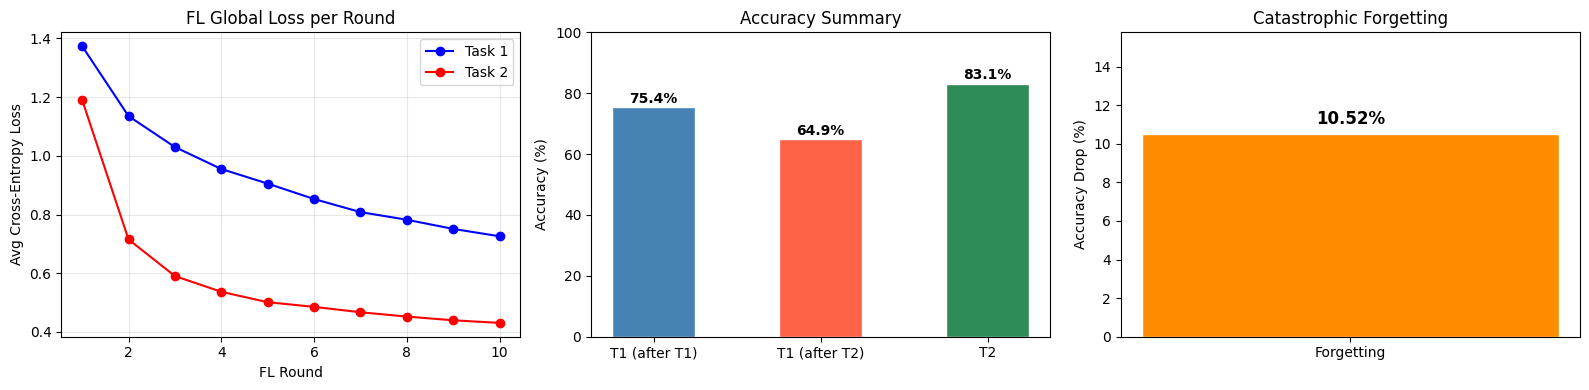

Chart saved: results.png


In [22]:
# ── Plot results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(range(1, FL_ROUNDS+1), task1_round_losses, 'b-o', label='Task 1')
axes[0].plot(range(1, FL_ROUNDS+1), task2_round_losses, 'r-o', label='Task 2')
axes[0].set_title('FL Global Loss per Round')
axes[0].set_xlabel('FL Round')
axes[0].set_ylabel('Avg Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy bar
bars   = ['T1 (after T1)', 'T1 (after T2)', 'T2']
vals   = [acc_t1_before, acc_t1_after, acc_t2_after]
colors = ['steelblue', 'tomato', 'seagreen']
axes[1].bar(bars, vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Accuracy Summary')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(vals):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Forgetting bar
axes[2].bar(['Forgetting'], [forgetting], color='darkorange', edgecolor='white', width=0.4)
axes[2].set_title('Catastrophic Forgetting')
axes[2].set_ylabel('Accuracy Drop (%)')
axes[2].set_ylim(0, max(forgetting * 1.5, 10))
axes[2].text(0, forgetting + 0.5, f'{forgetting:.2f}%', ha='center', fontsize=12,
             fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: results.png')

## 13. ONNX Export for Edge Deployment
Two separate ONNX models are exported — one per task — with the task mask baked in,  
so edge devices run a single clean forward pass with no dynamic masking logic.

In [23]:
# ── Wrapper: bakes task mask into the forward pass ────────────────────────────
# This produces a clean ONNX graph that works on any ONNX-compatible edge runtime
# (ONNX Runtime, TFLite via conversion, OpenVINO, etc.).

class MaskedModel(nn.Module):
    """Thin wrapper that hard-codes a fixed task mask into the forward pass."""
    def __init__(self, base_model, task_mask):
        super().__init__()
        self.base = base_model
        # Register as buffer so it is exported as a constant into ONNX
        self.register_buffer('task_mask', task_mask.clone())

    def forward(self, x):
        return self.base(x, self.task_mask)


def export_onnx(global_model, task_id, out_path):
    """
    FIX: copy.deepcopy().cpu() instead of .cpu() directly.
    Using .cpu() on the original model moves global_model in-place
    (PyTorch .to/.cpu returns self, not a copy), which would corrupt
    global_model's device and cause CUDA/CPU mismatch on all subsequent
    operations. deepcopy creates a fully independent copy.
    """
    cpu_base = copy.deepcopy(global_model).cpu().eval()
    mask_cpu = get_task_mask(task_id).cpu()
    wrapped  = MaskedModel(cpu_base, mask_cpu).eval()

    dummy_in = torch.randn(1, 3, 32, 32)
    torch.onnx.export(
        wrapped,
        dummy_in,
        out_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
        dynamo=False
    )
    size_kb = os.path.getsize(out_path) / 1024
    print(f'  Saved {out_path}  ({size_kb:.1f} KB)')
    return wrapped, cpu_base


print('Exporting ONNX models...')
_, cpu_model = export_onnx(global_model, task_id=1, out_path='model_task1_edge.onnx')
export_onnx(global_model,  task_id=2, out_path='model_task2_edge.onnx')
print('ONNX export complete.')

Exporting ONNX models...


/tmp/ipykernel_8549/856346794.py:30: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


  Saved model_task1_edge.onnx  (33831.3 KB)
  Saved model_task2_edge.onnx  (33831.3 KB)
ONNX export complete.


In [24]:
# ── INT8 Quantisation (optional) ─────────────────────────────────────────────
# ~3-4x smaller model, ~2x faster on CPU/edge, < 1% accuracy drop.

try:
    from onnxruntime.quantization import quantize_dynamic, QuantType

    for task_id in [1, 2]:
        fp32_path = f'model_task{task_id}_edge.onnx'
        int8_path = f'model_task{task_id}_edge_int8.onnx'
        quantize_dynamic(fp32_path, int8_path, weight_type=QuantType.QInt8)
        fp32_kb = os.path.getsize(fp32_path) / 1024
        int8_kb = os.path.getsize(int8_path) / 1024
        print(f'Task {task_id}  FP32: {fp32_kb:.1f} KB  ->  '
              f'INT8: {int8_kb:.1f} KB  ({fp32_kb/int8_kb:.1f}x smaller)')
    print('INT8 quantisation done.')
except Exception as e:
    print(f'Quantisation skipped: {e}')

Task 1  FP32: 33831.3 KB  ->  INT8: 8471.6 KB  (4.0x smaller)
Task 2  FP32: 33831.3 KB  ->  INT8: 8471.6 KB  (4.0x smaller)
INT8 quantisation done.


In [25]:
# ── TorchScript export — ONE file for mobile, all 10 classes ─────────────────

class FullModel(nn.Module):
    """Wrapper that runs the model with NO task mask — all 10 outputs active."""
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        return self.base(x, None)   # None = no mask, all 10 classes visible

# deepcopy so global_model stays on GPU
cpu_model = copy.deepcopy(global_model).cpu().eval()
wrapped   = FullModel(cpu_model).eval()

dummy_in = torch.randn(1, 3, 32, 32)
scripted  = torch.jit.trace(wrapped, dummy_in)
# ── TorchScript Lite export — Mobile optimized ─────────────────────────────

import copy
import os

class FullModel(nn.Module):
    """No mask — all 10 classes active"""
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        return self.base(x, None)

# Prepare model (SAFE: no GPU corruption)
cpu_model = copy.deepcopy(global_model).cpu().eval()
wrapped   = FullModel(cpu_model).eval()

dummy_in = torch.randn(1, 3, 32, 32)

# Trace
scripted = torch.jit.trace(wrapped, dummy_in)

# ✅ CORRECT for mobile (Lite Interpreter)
scripted._save_for_lite_interpreter("model_all10_mobile.ptl")

size_mb = os.path.getsize("model_all10_mobile.ptl") / (1024 * 1024)
print(f"Saved: model_all10_mobile.ptl ({size_mb:.2f} MB)")

size_mb = os.path.getsize('model_all10_mobile.ptl') / (1024 * 1024)
print(f'Mobile model saved: model_all10_mobile.ptl  ({size_mb:.2f} MB)')
print('Classifies all 10 CIFAR classes: airplane, auto, bird, cat, deer,')
print('                                  dog, frog, horse, ship, truck')
print()
print('Output index → class name:')
for i, name in enumerate(CLASSES):
    print(f'  [{i}] {name}')

Saved: model_all10_mobile.ptl (33.08 MB)
Mobile model saved: model_all10_mobile.ptl  (33.08 MB)
Classifies all 10 CIFAR classes: airplane, auto, bird, cat, deer,
                                  dog, frog, horse, ship, truck

Output index → class name:
  [0] airplane
  [1] automobile
  [2] bird
  [3] cat
  [4] deer
  [5] dog
  [6] frog
  [7] horse
  [8] ship
  [9] truck


/tmp/ipykernel_8549/3567582027.py:42: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  scripted._save_for_lite_interpreter("model_all10_mobile.ptl")


## 14. Edge Inference Demo


--- Edge Inference: Task 1 (classes 0-4) ---
  Model       : model_task1_edge.onnx
  True label  : 3 (cat)
  Predicted   : 3 (cat)
  Correct     : True
  Latency     : 3.46 ms/image  (~289 FPS on this CPU)
  Note        : On Raspberry Pi 4, expect ~10-50x slower.


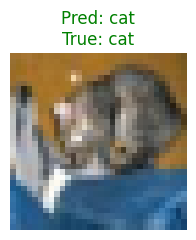


--- Edge Inference: Task 2 (classes 5-9) ---
  Model       : model_task2_edge.onnx
  True label  : 8 (ship)
  Predicted   : 8 (ship)
  Correct     : True
  Latency     : 3.20 ms/image  (~312 FPS on this CPU)
  Note        : On Raspberry Pi 4, expect ~10-50x slower.


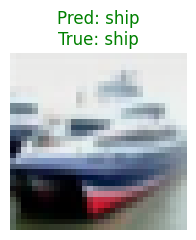

In [26]:
# ── ONNX Runtime edge inference ───────────────────────────────────────────────
import onnxruntime as ort
import time

def run_edge_demo(onnx_path, test_dataset, class_ids, task_label, n_runs=200):
    sess   = ort.InferenceSession(onnx_path,
                                  providers=['CPUExecutionProvider'])
    img, lbl = test_dataset[0]
    inp      = img.unsqueeze(0).numpy()

    # Latency benchmark
    start = time.perf_counter()
    for _ in range(n_runs):
        out = sess.run(['output'], {'input': inp})
    lat_ms = (time.perf_counter() - start) / n_runs * 1000

    logits = out[0]
    pred   = int(np.argmax(logits))

    print(f'\n--- Edge Inference: {task_label} ---')
    print(f'  Model       : {onnx_path}')
    print(f'  True label  : {lbl} ({CLASSES[lbl]})')
    print(f'  Predicted   : {pred} ({CLASSES[pred]})')
    print(f'  Correct     : {pred == lbl}')
    print(f'  Latency     : {lat_ms:.2f} ms/image  '
          f'(~{1000/lat_ms:.0f} FPS on this CPU)')
    print(f'  Note        : On Raspberry Pi 4, expect ~10-50x slower.')

    # Visualise
    img_show = img.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img_show = np.clip(img_show * std + mean, 0, 1)
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img_show)
    color = 'green' if pred == lbl else 'red'
    plt.title(f'Pred: {CLASSES[pred]}\nTrue: {CLASSES[lbl]}', color=color)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


run_edge_demo('model_task1_edge.onnx', task1_test, TASK1_CLASSES, 'Task 1 (classes 0-4)')
run_edge_demo('model_task2_edge.onnx', task2_test, TASK2_CLASSES, 'Task 2 (classes 5-9)')

## 15. Final Summary

In [27]:
# ── File manifest ─────────────────────────────────────────────────────────────
files = [
    'model_task1.pth', 'model_task2.pth',
    'model_task1_edge.onnx', 'model_task2_edge.onnx',
    'model_task1_edge_int8.onnx', 'model_task2_edge_int8.onnx',
    'model_task1_android.ptl', 'model_task2_android.ptl',
    'results.png',
]
print('\n' + '=' * 65)
print('FINAL SUMMARY — Sparse-FCL on CIFAR-10')
print('=' * 65)
print(f"{'Metric':<45} {'Value':>15}")
print('-' * 65)
print(f"{'Task 1 acc (after Task 1 only)':<45} {acc_t1_before:>14.2f}%")
print(f"{'Task 1 acc (after Task 2 train)':<45} {acc_t1_after:>14.2f}%")
print(f"{'Task 2 acc':<45} {acc_t2_after:>14.2f}%")
print(f"{'Catastrophic Forgetting (lower is better)':<45} {forgetting:>14.2f}%")
print(f"{'Actual sparsity':<45} {actual_sparsity:>14.1f}%")
print(f"{'Est. FL comm. reduction':<45} {actual_sparsity:>14.1f}%")
for f in files:
    if os.path.exists(f):
        kb = os.path.getsize(f) / 1024
        print(f"  {f:<43} {kb:>10.1f} KB")
print('=' * 65)
print('\nArchitecture details (paper spec):')
print('  Layer 1 : Conv2d(3->64,  3x3, stride=1, pad=1)')
print('  Layer 2 : Conv2d(64->64, 3x3, stride=1, pad=1) + MaxPool(2x2)')
print('  Layer 3 : Conv2d(64->128, 3x3, stride=1, pad=1)')
print('  Layer 4 : Conv2d(128->128, 3x3, stride=1, pad=1) + MaxPool(2x2)')
print('  Layer 5 : Linear(8192 -> 1024)  [8*8*128 = 8192 for CIFAR-32x32]')
print('  Layer 6 : Linear(1024 -> 10)    [task mask applied here]')
print(f'  Sparsity: {SPARSITY*100:.0f}% | Clients: {NUM_CLIENTS} | '
      f'LocalEpochs: {LOCAL_EPOCHS} | Batch: {BATCH_SIZE} | Dirichlet α={DIRICHLET_ALPHA}')


FINAL SUMMARY — Sparse-FCL on CIFAR-10
Metric                                                  Value
-----------------------------------------------------------------
Task 1 acc (after Task 1 only)                         75.38%
Task 1 acc (after Task 2 train)                        64.86%
Task 2 acc                                             83.08%
Catastrophic Forgetting (lower is better)              10.52%
Actual sparsity                                         81.0%
Est. FL comm. reduction                                 81.0%
  model_task1.pth                                33844.7 KB
  model_task2.pth                                33844.7 KB
  model_task1_edge.onnx                          33831.3 KB
  model_task2_edge.onnx                          33831.3 KB
  model_task1_edge_int8.onnx                      8471.6 KB
  model_task2_edge_int8.onnx                      8471.6 KB
  results.png                                       89.7 KB

Architecture details (paper spec):
  La

In [28]:
# ── Download ──────────────────────────────────────────────────────────────────
from google.colab import files
files.download('model_all10_mobile.ptl')
print('Download triggered: model_all10_mobile.ptl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered: model_all10_mobile.ptl
